# Detection Transformer（DETR）

[Carion et al. (2020), End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872)

これまでのTwo-stage系（アンカー・RPN・RoI Pooling）、One-stage系（アンカー・グリッド）、Anchor-free系（centerness）は、いずれも「大量の候補（アンカーやグリッドセル、画素）を用意し、そこから重複した予測をNMSで間引く」という設計だった。**DETR（DEtection TRansformer）** は、物体検出を**集合予測（set prediction）問題**として定式化し直すことで、アンカー・RPN・NMSといった手作りのコンポーネントを一切使わずに、CNN＋Transformerのみでend-to-endに学習できるようにした。

## アーキテクチャ

1. **CNNバックボーン**（ResNetなど）で画像から特徴マップを抽出する
2. 特徴マップを1次元に平坦化し、位置エンコーディング（positional encoding）を加えて**Transformer Encoder**に入力する（各位置間の関係をSelf-Attentionで学習する）
3. 学習可能な $N$ 個のベクトル（**object queries**、$N=100$ 程度、画像中に存在しうる物体数の上限として十分大きく取る）を**Transformer Decoder**に入力する。DecoderはEncoderの出力に対してCross-Attentionを行い、各object queryを1つの物体（または「物体なし」）に対応する出力に変換する
4. 各queryの出力をFFN（Feed-Forward Network）に通し、クラスラベル（「物体なし」クラスを含む）とバウンディングボックス $(cx, cy, w, h)$（画像サイズで正規化）を予測する

出力は常に固定長 $N$ 個の予測だが、実際の物体数は画像ごとに異なるため、多くのqueryは「物体なし（$\varnothing$）」を予測することになる。NMSのような後処理なしで、Decoderのself-attention同士が「同じ物体を2つのqueryが重複して予測しないように」相互作用することを学習で獲得する。

## 二部マッチングによる集合予測損失

出力が固定長 $N$ 個の予測集合であるのに対し、正解も可変個のボックス集合 $y = \{y_1, \ldots, y_M\}$（$M \leq N$、足りない分は「物体なし」$\varnothing$ でパディングして長さ $N$ にそろえる）として与えられる。学習にあたっては、$N$個の予測と$N$個の正解（パディング含む）の**最適な1対1対応**を見つける必要がある。

DETRはこれを**二部マッチング問題（bipartite matching）**として定式化し、**ハンガリアン法（Hungarian algorithm）** で解く。

$$
\hat{\sigma} = \arg\min_{\sigma \in \mathfrak{S}_N} \sum_{i=1}^{N} L_{\mathrm{match}}(y_i, \hat{y}_{\sigma(i)})
$$

- $\mathfrak{S}_N$：$N$個の要素の置換全体の集合
- $\sigma$：予測と正解の対応付け（どの予測がどの正解を担当するか）
- $L_{\mathrm{match}}$：ペアごとのマッチングコスト。分類確率とボックスの類似度から計算する

$$
L_{\mathrm{match}}(y_i, \hat{y}_{\sigma(i)}) = -\mathbb{1}_{\{c_i \neq \varnothing\}}\, \hat{p}_{\sigma(i)}(c_i) + \mathbb{1}_{\{c_i \neq \varnothing\}}\, L_{\mathrm{box}}(b_i, \hat{b}_{\sigma(i)})
$$

最適な対応 $\hat{\sigma}$ が見つかったら、通常のcross entropy損失とbbox損失を、その対応にもとづいて計算する（**Hungarian loss**）。

$$
L_{\mathrm{Hungarian}}(y, \hat{y}) = \sum_{i=1}^{N} \left[ -\log \hat{p}_{\hat{\sigma}(i)}(c_i) + \mathbb{1}_{\{c_i \neq \varnothing\}}\, L_{\mathrm{box}}(b_i, \hat{b}_{\hat{\sigma}(i)}) \right]
$$

このマッチングにより、各正解ボックスに対して「担当する予測」がちょうど1つに決まるため、複数の予測が同じ物体に重複して割り当てられることがなくなる。学習がうまく進めば、推論時にもqueryごとの出力がほぼ重複しなくなり、**NMSなしでそのまま最終出力として使える**。

## ボックス損失：$L_1$ + GIoU

ボックス回帰の損失 $L_{\mathrm{box}}$ には、$L_1$損失とGIoU損失を組み合わせて使う。

$$
L_{\mathrm{box}}(b_i, \hat{b}_{\sigma(i)}) = \lambda_{\mathrm{iou}}\, L_{\mathrm{iou}}(b_i, \hat{b}_{\sigma(i)}) + \lambda_{L1}\, \lVert b_i - \hat{b}_{\sigma(i)} \rVert_1
$$

単純な$L_1$損失だけだと、大きいボックスと小さいボックスで同じ絶対誤差でも意味合いが異なってしまう（スケール依存）。かといって通常のIoUは、2つのボックスが**全く重なっていない**場合に常に0になり、「どれだけ離れているか」の勾配が得られない。

**GIoU（Generalized IoU）**（[Rezatofighi et al., 2019](https://arxiv.org/abs/1902.09630)）はこれを解消する。2つのボックス $A, B$ を囲む最小の矩形を $C$ とすると、

$$
\mathrm{GIoU}(A, B) = \mathrm{IoU}(A, B) - \frac{|C \setminus (A \cup B)|}{|C|}
$$

$\mathrm{GIoU} \in [-1, 1]$ で、重なりがない場合でも $C$ に対する隙間の割合に応じて $-1$ に向かって連続的に値が変化するため、重なりがないボックス同士でも意味のある勾配が得られる。$L_{\mathrm{iou}} = 1 - \mathrm{GIoU}$ として損失に使う。

## 特徴とトレードオフ

**メリット**

- アンカー生成、RPN、NMSなど手作りのコンポーネントが不要になり、パイプライン全体がシンプルになる
- Self-Attentionにより画像全体の大域的な文脈を捉えられるため、重なり合った物体や大きな物体の検出に強い

**デメリット**

- 学習の収束が非常に遅い（原論文ではCOCOで500 epoch学習しており、Faster R-CNNの数十epochに比べて大幅に多い）
- Encoderの計算量が特徴マップの画素数に対して2乗オーダー（$O(H^2W^2)$）で増えるため、高解像度の特徴マップを使いにくく、小さい物体の検出精度が相対的に弱い

この「収束の遅さ」と「小物体への弱さ」を、Self-AttentionをすべてのピクセルではなくCross-Attention由来の少数のサンプリング点に限定することで解決しようとしたのが、次に扱う **Deformable DETR** になる。

## 実行例：DETR による推論

Facebook Researchの公式実装を `torch.hub` 経由で読み込み、COCO事前学習済みの `detr_resnet50` でサンプル画像を検出する。

Using cache found in /home/mitama/.cache/torch/hub/facebookresearch_detr_main


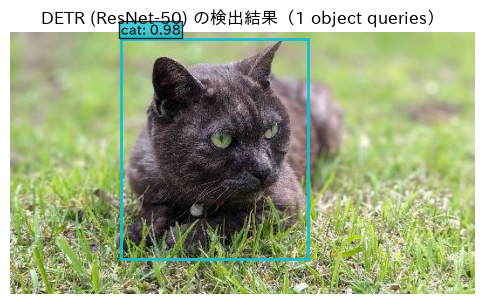

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib_fontja
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

# facebookresearch/detr のResNetバックボーン読み込みが torchvision の非推奨API(pretrained=)を
# 内部で使っているため出るUserWarningを抑制する
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    model = torch.hub.load("facebookresearch/detr", "detr_resnet50", pretrained=True)
model.eval()

# DETRの出力クラス数(92) = COCOの91クラス(背景/N/Aを含む、torchvisionの命名と同一のインデックス) + "no object"
categories = FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta["categories"]

transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def box_cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    return torch.stack([cx - 0.5 * w, cy - 0.5 * h, cx + 0.5 * w, cy + 0.5 * h], dim=-1)


img = Image.open("../sample_images/cat1.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    output = model(x)

probs = output["pred_logits"].softmax(-1)[0, :, :-1]  # 最後の"no object"クラスを除く
scores, labels = probs.max(-1)
score_threshold = 0.7
keep = scores > score_threshold

boxes = box_cxcywh_to_xyxy(output["pred_boxes"][0, keep])
boxes = boxes * torch.tensor([img.width, img.height, img.width, img.height])

fig, ax = plt.subplots(figsize=[6, 4])
ax.imshow(img)
for box, label, score in zip(boxes, labels[keep], scores[keep]):
    x0, y0, x1, y1 = box.tolist()
    ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="tab:cyan", facecolor="none"))
    ax.text(x0, y0 - 5, f"{categories[label]}: {score:.2f}", color="black",
            bbox=dict(facecolor="tab:cyan", alpha=0.8, pad=1))
ax.set_title(f"DETR (ResNet-50) の検出結果（{keep.sum().item()} object queries）")
ax.axis("off")
plt.show()

## 参考文献

- Carion, N. et al. (2020). [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872)
- Rezatofighi, H. et al. (2019). [Generalized Intersection over Union](https://arxiv.org/abs/1902.09630)
- [facebookresearch/detr — GitHub](https://github.com/facebookresearch/detr)
- Kuhn, H. W. (1955). The Hungarian Method for the assignment problem